<a href="https://colab.research.google.com/github/KESHAV8087/KESHAV8087/blob/main/phishing_bilstm_themis_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Environment check
import torch
import pandas as pd
import numpy as np
import sys

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device will be: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Python: 3.12.13
PyTorch: 2.10.0+cu128
CUDA available: True
Device will be: cuda


In [3]:
# Load and verify
df = pd.read_excel('phishing_site_urls.xlsx')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nClass distribution:")
print(df['label'].value_counts())
print(f"\nNulls: {df.isnull().sum().sum()}")
df.head()

Shape: (549346, 2)
Columns: ['URL', 'label']

Class distribution:
label
good    392924
bad     156422
Name: count, dtype: int64

Nulls: 1


,URL,label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [4]:
# Clean and create a stratified 50K subsample
from sklearn.model_selection import train_test_split

# Drop nulls
df_clean = df.dropna(subset=['URL']).reset_index(drop=True)
print(f"After dropping nulls: {df_clean.shape}")

# Drop exact duplicate URLs (prevents train/test leakage later)
df_clean = df_clean.drop_duplicates(subset=['URL']).reset_index(drop=True)
print(f"After dropping duplicate URLs: {df_clean.shape}")

# Stratified subsample to 50K (keeps class proportions)
df_sample, _ = train_test_split(
    df_clean,
    train_size=50000,
    stratify=df_clean['label'],
    random_state=42
)
df_sample = df_sample.reset_index(drop=True)

print(f"\nFinal subsample shape: {df_sample.shape}")
print(f"Class distribution in subsample:")
print(df_sample['label'].value_counts())
print(f"\nClass proportions:")
print(df_sample['label'].value_counts(normalize=True).round(4))

After dropping nulls: (549345, 2)
After dropping duplicate URLs: (507194, 2)

Final subsample shape: (50000, 2)
Class distribution in subsample:
label
good    38732
bad     11268
Name: count, dtype: int64

Class proportions:
label
good    0.7746
bad     0.2254
Name: proportion, dtype: float64


URL length stats — overall:
count    50000.0
mean        51.7
std         43.3
min          7.0
25%         30.0
50%         41.0
75%         60.0
max       1383.0
Name: url_len, dtype: float64

URL length stats — by class:
         count  mean   std  min   25%   50%   75%     max
label                                                    
bad    11268.0  71.8  75.2  8.0  30.0  48.0  83.0  1383.0
good   38732.0  45.8  25.0  7.0  30.0  40.0  56.0   702.0
  90th percentile of length: 86
  95th percentile of length: 112
  99th percentile of length: 233
  99.5th percentile of length: 309

Unique characters in dataset: 165
Sample of chars: ['\t', '\n', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


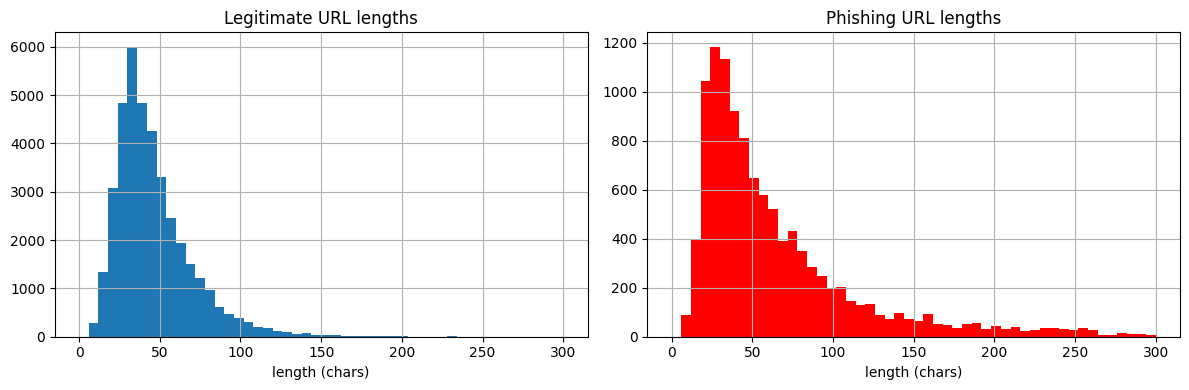

In [5]:
# EDA - URL length, character set, by-class differences
import matplotlib.pyplot as plt

# URL length stats overall and by class
df_sample['url_len'] = df_sample['URL'].str.len()
print("URL length stats — overall:")
print(df_sample['url_len'].describe().round(1))

print("\nURL length stats — by class:")
print(df_sample.groupby('label')['url_len'].describe().round(1))

# What max length covers most URLs?
for pct in [90, 95, 99, 99.5]:
    val = np.percentile(df_sample['url_len'], pct)
    print(f"  {pct}th percentile of length: {val:.0f}")

# Character set inventory
all_chars = set(''.join(df_sample['URL'].tolist()))
print(f"\nUnique characters in dataset: {len(all_chars)}")
print(f"Sample of chars: {sorted(list(all_chars))[:60]}")

# Plot length distribution by class
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df_sample[df_sample['label']=='good']['url_len'].hist(bins=50, ax=ax[0], range=(0,300))
ax[0].set_title('Legitimate URL lengths')
ax[0].set_xlabel('length (chars)')
df_sample[df_sample['label']=='bad']['url_len'].hist(bins=50, ax=ax[1], range=(0,300), color='red')
ax[1].set_title('Phishing URL lengths')
ax[1].set_xlabel('length (chars)')
plt.tight_layout()
plt.show()

In [6]:
# Split into train/val/test BEFORE building vocab (no leakage)
from sklearn.model_selection import train_test_split

# Map labels to integers: bad=1 (positive class = phishing), good=0
df_sample['y'] = (df_sample['label'] == 'bad').astype(int)

# Strip stray whitespace/control chars from URLs (the \t and \n we saw)
df_sample['URL'] = df_sample['URL'].str.replace(r'[\t\n\r]', '', regex=True).str.strip()

# First split: 70% train, 30% temp
train_df, temp_df = train_test_split(
    df_sample,
    train_size=0.70,
    stratify=df_sample['y'],
    random_state=42
)
# Second split: 15% val, 15% test (= split the 30% in half)
val_df, test_df = train_test_split(
    temp_df,
    train_size=0.50,
    stratify=temp_df['y'],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} ({train_df['y'].mean():.3f} phishing)")
print(f"Val:   {len(val_df)} ({val_df['y'].mean():.3f} phishing)")
print(f"Test:  {len(test_df)} ({test_df['y'].mean():.3f} phishing)")

# Sanity check: no URL appears in more than one split
train_urls = set(train_df['URL'])
val_urls = set(val_df['URL'])
test_urls = set(test_df['URL'])
print(f"\nLeakage check (should all be 0):")
print(f"  train ∩ val:  {len(train_urls & val_urls)}")
print(f"  train ∩ test: {len(train_urls & test_urls)}")
print(f"  val ∩ test:   {len(val_urls & test_urls)}")

Train: 35000 (0.225 phishing)
Val:   7500 (0.225 phishing)
Test:  7500 (0.225 phishing)

Leakage check (should all be 0):
  train ∩ val:  0
  train ∩ test: 0
  val ∩ test:   0


In [7]:
# Character-level tokenization
from collections import Counter

MAX_LEN = 200

# Build vocab from TRAINING SET ONLY
char_counts = Counter()
for url in train_df['URL']:
    char_counts.update(url)

# Reserve index 0 for <PAD>, 1 for <UNK>. All other chars get index 2+.
# We keep all chars that appear in training (no min count threshold for now)
vocab = {'<PAD>': 0, '<UNK>': 1}
for ch, _ in char_counts.most_common():
    vocab[ch] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f"Vocab size: {VOCAB_SIZE} (including <PAD> and <UNK>)")
print(f"Top 20 most common chars: {[ch for ch, _ in char_counts.most_common(20)]}")

# Encoding function: string -> list of int IDs, padded/truncated to MAX_LEN
def encode(url, max_len=MAX_LEN):
    ids = [vocab.get(ch, vocab['<UNK>']) for ch in url[:max_len]]
    # Pad to max_len with <PAD>=0
    ids = ids + [0] * (max_len - len(ids))
    return ids

# Encode all splits (returns numpy arrays of shape [N, MAX_LEN])
X_train = np.array([encode(u) for u in train_df['URL']], dtype=np.int64)
X_val   = np.array([encode(u) for u in val_df['URL']],   dtype=np.int64)
X_test  = np.array([encode(u) for u in test_df['URL']],  dtype=np.int64)

y_train = train_df['y'].values.astype(np.int64)
y_val   = val_df['y'].values.astype(np.int64)
y_test  = test_df['y'].values.astype(np.int64)

print(f"\nShapes:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}, y_test:  {y_test.shape}")

# How many test URLs contain OOV characters (chars not in train vocab)?
oov_count = sum(1 for u in test_df['URL'] if any(ch not in vocab for ch in u))
print(f"\nTest URLs containing OOV chars: {oov_count} ({100*oov_count/len(test_df):.2f}%)")

# Show one encoded example
print(f"\nExample URL: {train_df['URL'].iloc[0][:80]}...")
print(f"Encoded (first 30 ids): {X_train[0][:30].tolist()}")
print(f"Label: {y_train[0]} ({'bad' if y_train[0]==1 else 'good'})")

Vocab size: 165 (including <PAD> and <UNK>)
Top 20 most common chars: ['e', 'o', 'a', '/', 'i', 't', 'c', 's', 'r', 'n', 'm', '.', 'l', 'd', 'p', '-', 'h', 'u', 'g', 'w']

Shapes:
  X_train: (35000, 200), y_train: (35000,)
  X_val:   (7500, 200), y_val:   (7500,)
  X_test:  (7500, 200), y_test:  (7500,)

Test URLs containing OOV chars: 0 (0.00%)

Example URL: news.theopenmat.com/2011/11/cowboys-win-nine-titles-at-ucm-open/...
Encoded (first 30 ids): [11, 2, 21, 9, 13, 7, 18, 2, 3, 16, 2, 11, 12, 4, 7, 13, 8, 3, 12, 5, 27, 24, 25, 25, 5, 25, 25, 5, 8, 3]
Label: 0 (good)


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


class BiLSTMPhishingClassifier(nn.Module):
    """
    Character-level Bi-LSTM for phishing URL classification.

    Architecture (input -> output):
        1. Embedding:    char_id (int)        -> dense vector  [B, L]      -> [B, L, E]
        2. Bi-LSTM:      sequence of vectors  -> hidden states [B, L, E]   -> [B, L, 2H]
        3. Pooling:      max over time dim    -> single vector [B, L, 2H]  -> [B, 2H]
        4. Dropout:      regularization
        5. Linear:       2H -> 1 logit        (binary classification)

    Shapes use B = batch size, L = seq length (200), E = embed dim, H = hidden dim.
    Bi-LSTM doubles the hidden state because it concatenates forward and backward.
    """

    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128,
                 num_layers=1, dropout=0.3, pad_idx=0):
        super().__init__()
        # padding_idx=0 means the embedding for <PAD> is fixed at zero and not learned —
        # so padded positions contribute nothing meaningful to downstream computation
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,    # input shape (B, L, E) instead of (L, B, E)
            bidirectional=True,  # forward + backward passes, outputs concatenated
            dropout=0.0          # dropout between LSTM layers — only matters if num_layers > 1
        )

        self.dropout = nn.Dropout(dropout)
        # 2 * hidden_dim because bi-directional concatenates forward + backward states
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        # x: (B, L) integer token IDs
        emb = self.embedding(x)              # (B, L, embed_dim)
        lstm_out, _ = self.lstm(emb)         # (B, L, 2*hidden_dim)

        # Max-pool over time dimension: for each of the 2H features, take the max
        # activation across all L timesteps. This gives a single fixed-size vector per
        # URL regardless of length, and lets the model "focus on" the most informative
        # timesteps rather than averaging signal away.
        pooled, _ = lstm_out.max(dim=1)      # (B, 2*hidden_dim)

        out = self.dropout(pooled)
        logits = self.fc(out).squeeze(-1)    # (B,) — one logit per example
        return logits


# Instantiate
model = BiLSTMPhishingClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=64,
    hidden_dim=128,
    num_layers=1,
    dropout=0.3,
).to(device)

# Parameter count — useful for "how big is your model" interview questions
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel parameters: {total_params:,} total, {trainable_params:,} trainable")
print(model)

# Smoke test: forward pass on a batch of 16
x_batch = torch.tensor(X_train[:16], dtype=torch.long, device=device)
y_batch = torch.tensor(y_train[:16], dtype=torch.float, device=device)

# Removed torch.no_grad() for the gradient flow check
logits = model(x_batch)

print(f"\nSmoke test:")
print(f"  Input shape:  {tuple(x_batch.shape)}")
print(f"  Output shape: {tuple(logits.shape)}")
print(f"  Sample logits: {logits[:5].cpu().numpy().round(3)}")
print(f"  Sample probs:  {torch.sigmoid(logits[:5]).cpu().numpy().round(3)}")

# Verify gradients flow
loss = F.binary_cross_entropy_with_logits(logits, y_batch)
loss.backward()
grad_norms = [p.grad.norm().item() for p in model.parameters() if p.grad is not None]
print(f"\nGradient flow check:")
print(f"  Loss: {loss.item():.4f}")
print(f"  Number of params with gradient: {len(grad_norms)}")
print(f"  Min/max grad norm: {min(grad_norms):.4f} / {max(grad_norms):.4f}")

Using device: cuda

Model parameters: 209,473 total, 209,473 trainable
BiLSTMPhishingClassifier(
  (embedding): Embedding(165, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)

Smoke test:
  Input shape:  (16, 200)
  Output shape: (16,)
  Sample logits: [-0.218 -0.421 -0.192 -0.32  -0.18 ]
  Sample probs:  [0.446 0.396 0.452 0.421 0.455]


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [9]:
# Cell 8b: Re-run gradient flow check WITHOUT torch.no_grad()
import torch.nn.functional as F

# Same inputs as before
x_batch = torch.tensor(X_train[:16], dtype=torch.long, device=device)
y_batch = torch.tensor(y_train[:16], dtype=torch.float, device=device)

# Forward pass WITH gradient tracking this time
model.zero_grad()
logits = model(x_batch)
loss = F.binary_cross_entropy_with_logits(logits, y_batch)
loss.backward()

grad_norms = [p.grad.norm().item() for p in model.parameters() if p.grad is not None]
print(f"Gradient flow check:")
print(f"  Loss: {loss.item():.4f}  (expect ~0.5–0.8 at init for binary task)")
print(f"  Number of params with gradient: {len(grad_norms)}")
print(f"  Min/max grad norm: {min(grad_norms):.4f} / {max(grad_norms):.4f}")
print(f"  All gradients non-zero: {all(g > 0 for g in grad_norms)}")

Gradient flow check:
  Loss: 0.6391  (expect ~0.5–0.8 at init for binary task)
  Number of params with gradient: 11
  Min/max grad norm: 0.0109 / 0.6984
  All gradients non-zero: True


In [10]:
# Cell 9: PyTorch Datasets and DataLoaders
from torch.utils.data import Dataset, DataLoader

class URLDataset(Dataset):
    """Wraps the encoded URL arrays into a PyTorch Dataset."""
    def __init__(self, X, y):
        # Pre-convert to tensors once, not per __getitem__ call (faster)
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 128

train_ds = URLDataset(X_train, y_train)
val_ds   = URLDataset(X_val,   y_val)
test_ds  = URLDataset(X_test,  y_test)

# shuffle=True for train only — val/test should be deterministic
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Batches per epoch — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

# Sanity: pull one batch and look at shapes
xb, yb = next(iter(train_loader))
print(f"\nOne batch — X: {tuple(xb.shape)}, y: {tuple(yb.shape)}")
print(f"y values in this batch (first 20): {yb[:20].int().tolist()}")
print(f"Phishing proportion in this batch: {yb.mean().item():.3f}")

Batches per epoch — train: 274, val: 59, test: 59

One batch — X: (128, 200), y: (128,)
y values in this batch (first 20): [0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
Phishing proportion in this batch: 0.250


In [11]:
# Cell 10: Compute positive-class weight for BCEWithLogitsLoss
#
# Why: 22.5% positive (phishing) means a naive classifier that always predicts "good"
# gets 77.5% accuracy. To force the model to actually learn the minority class, we
# up-weight phishing examples in the loss. The standard formula for pos_weight in
# nn.BCEWithLogitsLoss is num_negatives / num_positives.

n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)
pos_weight_val = n_neg / n_pos
pos_weight = torch.tensor([pos_weight_val], device=device)

print(f"Training set: {n_pos} phishing, {n_neg} legitimate")
print(f"pos_weight for loss: {pos_weight_val:.3f}")
print(f"  (interpretation: each phishing example counts {pos_weight_val:.2f}x as much as legitimate)")

Training set: 7888 phishing, 27112 legitimate
pos_weight for loss: 3.437
  (interpretation: each phishing example counts 3.44x as much as legitimate)


In [12]:
# Cell 11: Training and evaluation helpers
import time
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)


def train_one_epoch(model, loader, optimizer, criterion, device, clip_grad=1.0):
    """One pass over training data. Returns average loss."""
    model.train()  # IMPORTANT: enables dropout
    total_loss = 0.0
    n_seen = 0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        # Gradient clipping prevents the rare exploding-gradient that can occur
        # with LSTMs. Clips the L2 norm of all gradients combined to <= clip_grad.
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

        optimizer.step()

        # Weight by batch size in case last batch is smaller
        total_loss += loss.item() * xb.size(0)
        n_seen += xb.size(0)
    return total_loss / n_seen


@torch.no_grad()  # disables gradient tracking — faster, less memory
def evaluate(model, loader, criterion, device):
    """Returns (avg_loss, accuracy, precision, recall, f1, roc_auc, probs_array, labels_array)."""
    model.eval()  # IMPORTANT: disables dropout, switches BN to running stats (we have no BN here, but habit)
    total_loss = 0.0
    n_seen = 0
    all_probs = []
    all_labels = []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        n_seen += xb.size(0)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(yb.cpu().numpy())

    import numpy as np
    probs = np.concatenate(all_probs)
    labels = np.concatenate(all_labels).astype(int)
    preds = (probs >= 0.5).astype(int)

    metrics = {
        'loss':      total_loss / n_seen,
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall':    recall_score(labels, preds, zero_division=0),
        'f1':        f1_score(labels, preds, zero_division=0),
        'roc_auc':   roc_auc_score(labels, probs),
    }
    return metrics, probs, labels


print("Training and evaluation helpers defined.")

Training and evaluation helpers defined.


In [13]:
# Cell 12: Train with early stopping on val loss
import copy

# Re-instantiate model fresh (so re-running this cell starts from scratch)
model = BiLSTMPhishingClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=64,
    hidden_dim=128,
    num_layers=1,
    dropout=0.3,
).to(device)

# Optimizer: Adam is the standard choice for LSTMs.
# Default lr=1e-3 works well; weight_decay adds mild L2 regularization.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Loss: BCEWithLogitsLoss combines sigmoid + BCE in a numerically stable way.
# We pass our pos_weight to handle class imbalance.
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Training config
MAX_EPOCHS = 10
PATIENCE = 2          # stop if val_loss doesn't improve for this many epochs
best_val_loss = float('inf')
best_state = None
epochs_without_improvement = 0
history = []          # for plotting later

print(f"Training on {device} for up to {MAX_EPOCHS} epochs (early stop patience={PATIENCE})\n")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>9} | {'Val Acc':>8} | {'Val F1':>7} | {'Val AUC':>8} | {'Time':>5}")
print("-" * 75)

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_metrics, _, _ = evaluate(model, val_loader, criterion, device)
    elapsed = time.time() - t0

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_metrics['loss'],
        'val_acc':  val_metrics['accuracy'],
        'val_f1':   val_metrics['f1'],
        'val_auc':  val_metrics['roc_auc'],
    })

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_metrics['loss']:>9.4f} | "
          f"{val_metrics['accuracy']:>8.4f} | {val_metrics['f1']:>7.4f} | "
          f"{val_metrics['roc_auc']:>8.4f} | {elapsed:>4.1f}s")

    # Early stopping: save best model by val loss
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
            break

# Restore best weights
model.load_state_dict(best_state)
print(f"\nTraining complete. Best val_loss: {best_val_loss:.4f}")

Training on cuda for up to 10 epochs (early stop patience=2)

Epoch | Train Loss |  Val Loss |  Val Acc |  Val F1 |  Val AUC |  Time
---------------------------------------------------------------------------
    1 |     0.6346 |    0.4250 |   0.8796 |  0.7667 |   0.9544 |  6.1s
    2 |     0.3839 |    0.3595 |   0.9001 |  0.8053 |   0.9694 |  5.5s
    3 |     0.3098 |    0.3111 |   0.9403 |  0.8698 |   0.9750 |  5.7s
    4 |     0.2668 |    0.2771 |   0.9321 |  0.8604 |   0.9801 |  5.7s
    5 |     0.2290 |    0.2583 |   0.9443 |  0.8811 |   0.9824 |  5.5s
    6 |     0.2016 |    0.2852 |   0.9557 |  0.9004 |   0.9820 |  5.7s
    7 |     0.1751 |    0.2541 |   0.9527 |  0.8967 |   0.9840 |  5.6s
    8 |     0.1568 |    0.2480 |   0.9499 |  0.8924 |   0.9849 |  5.7s
    9 |     0.1377 |    0.2636 |   0.9508 |  0.8942 |   0.9844 |  5.6s
   10 |     0.1198 |    0.3041 |   0.9613 |  0.9127 |   0.9840 |  5.7s

Early stopping at epoch 10 (no improvement for 2 epochs).

Training complete. Be

In [14]:
# Cell 13: Final evaluation on the held-out test set
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)

test_metrics, test_probs, test_labels = evaluate(model, test_loader, criterion, device)

print("=" * 60)
print("TEST SET RESULTS (model never saw these URLs during training)")
print("=" * 60)
print(f"  Test Loss:      {test_metrics['loss']:.4f}")
print(f"  Test Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"  Test Precision: {test_metrics['precision']:.4f}  (of URLs we flag as phishing, % actually phishing)")
print(f"  Test Recall:    {test_metrics['recall']:.4f}  (of actual phishing URLs, % we catch)")
print(f"  Test F1:        {test_metrics['f1']:.4f}")
print(f"  Test ROC-AUC:   {test_metrics['roc_auc']:.4f}")

# Predictions at the default 0.5 threshold
test_preds = (test_probs >= 0.5).astype(int)

# Confusion matrix — rows=true, cols=predicted
cm = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm.ravel()

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
print(f"                    Predicted Legit | Predicted Phishing")
print(f"  Actual Legit      {tn:>14}  | {fp:>17}")
print(f"  Actual Phishing   {fn:>14}  | {tp:>17}")
print(f"\n  True Negatives  (legit correctly let through):    {tn}")
print(f"  False Positives (legit flagged as phishing — bad UX): {fp}")
print(f"  False Negatives (phishing missed — DANGEROUS):       {fn}")
print(f"  True Positives  (phishing correctly caught):         {tp}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(test_labels, test_preds,
                            target_names=['Legitimate', 'Phishing'],
                            digits=4))

TEST SET RESULTS (model never saw these URLs during training)
  Test Loss:      0.2413
  Test Accuracy:  0.9461
  Test Precision: 0.8518  (of URLs we flag as phishing, % actually phishing)
  Test Recall:    0.9213  (of actual phishing URLs, % we catch)
  Test F1:        0.8852
  Test ROC-AUC:   0.9856

CONFUSION MATRIX
                    Predicted Legit | Predicted Phishing
  Actual Legit                5539  |               271
  Actual Phishing              133  |              1557

  True Negatives  (legit correctly let through):    5539
  False Positives (legit flagged as phishing — bad UX): 271
  False Negatives (phishing missed — DANGEROUS):       133
  True Positives  (phishing correctly caught):         1557

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Legitimate     0.9766    0.9534    0.9648      5810
    Phishing     0.8518    0.9213    0.8852      1690

    accuracy                         0.9461      7500
   macro avg     0.9142    0.937

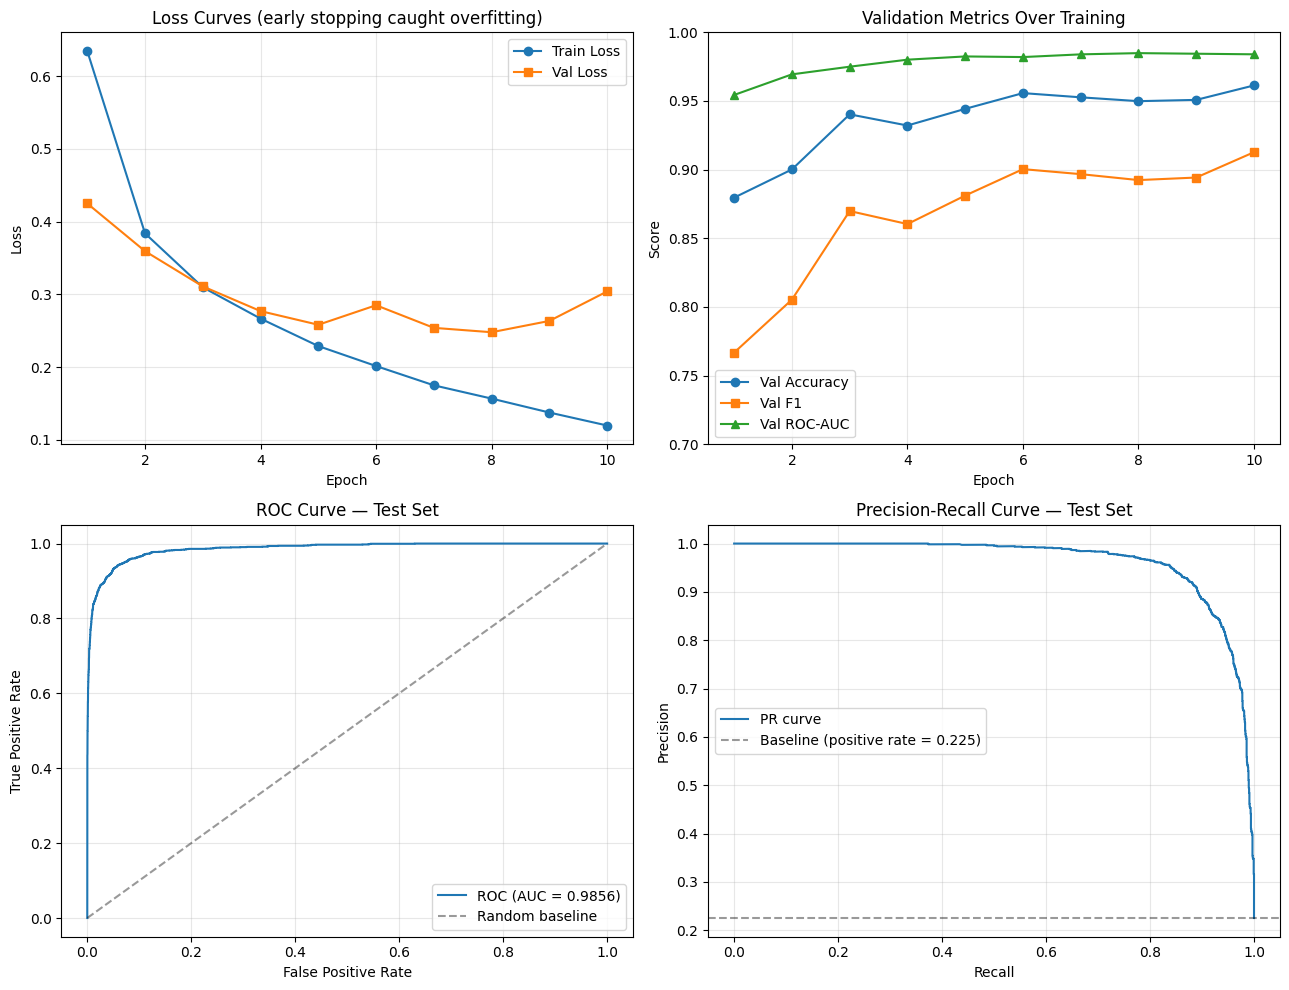

Saved bilstm_results.png


In [15]:
# Cell 14: Visualizations — learning curves + ROC + PR curves
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# --- Plot 1: Loss curves ---
epochs = [h['epoch'] for h in history]
axes[0,0].plot(epochs, [h['train_loss'] for h in history], 'o-', label='Train Loss')
axes[0,0].plot(epochs, [h['val_loss']   for h in history], 's-', label='Val Loss')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].set_title('Loss Curves (early stopping caught overfitting)')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# --- Plot 2: Val metrics over training ---
axes[0,1].plot(epochs, [h['val_acc'] for h in history], 'o-', label='Val Accuracy')
axes[0,1].plot(epochs, [h['val_f1']  for h in history], 's-', label='Val F1')
axes[0,1].plot(epochs, [h['val_auc'] for h in history], '^-', label='Val ROC-AUC')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Score')
axes[0,1].set_title('Validation Metrics Over Training')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3); axes[0,1].set_ylim([0.7, 1.0])

# --- Plot 3: ROC curve on test set ---
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1,0].plot(fpr, tpr, label=f"ROC (AUC = {test_metrics['roc_auc']:.4f})")
axes[1,0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random baseline')
axes[1,0].set_xlabel('False Positive Rate'); axes[1,0].set_ylabel('True Positive Rate')
axes[1,0].set_title('ROC Curve — Test Set')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# --- Plot 4: Precision-Recall curve (more informative than ROC for imbalanced data) ---
precision_vals, recall_vals, _ = precision_recall_curve(test_labels, test_probs)
axes[1,1].plot(recall_vals, precision_vals, label='PR curve')
axes[1,1].axhline(y=test_labels.mean(), color='k', linestyle='--', alpha=0.4,
                  label=f'Baseline (positive rate = {test_labels.mean():.3f})')
axes[1,1].set_xlabel('Recall'); axes[1,1].set_ylabel('Precision')
axes[1,1].set_title('Precision-Recall Curve — Test Set')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('bilstm_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved bilstm_results.png")

In [16]:
# Cell 15: Save everything needed to reproduce / deploy
import json
import torch

# Save model weights
torch.save(model.state_dict(), 'bilstm_phishing_model.pt')

# Save vocab (char -> int mapping) as JSON
with open('vocab.json', 'w') as f:
    json.dump(vocab, f)

# Save the model config and final metrics — useful for the README
config = {
    'model_type': 'Character-level Bi-LSTM',
    'vocab_size': VOCAB_SIZE,
    'embed_dim': 64,
    'hidden_dim': 128,
    'num_layers': 1,
    'dropout': 0.3,
    'max_len': MAX_LEN,
    'batch_size': BATCH_SIZE,
    'optimizer': 'Adam (lr=1e-3, weight_decay=1e-5)',
    'loss': 'BCEWithLogitsLoss with pos_weight',
    'pos_weight': float(pos_weight_val),
    'train_size': len(X_train),
    'val_size':   len(X_val),
    'test_size':  len(X_test),
    'class_distribution_test': {'legitimate': int((y_test == 0).sum()),
                                'phishing':   int((y_test == 1).sum())},
    'test_metrics': {k: float(v) for k, v in test_metrics.items()},
    'best_val_loss': float(best_val_loss),
}
with open('config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Saved:")
print("  - bilstm_phishing_model.pt  (model weights)")
print("  - vocab.json                (char -> int mapping)")
print("  - config.json               (hyperparams + metrics)")
print("  - bilstm_results.png        (plots from Cell 14)")

Saved:
  - bilstm_phishing_model.pt  (model weights)
  - vocab.json                (char -> int mapping)
  - config.json               (hyperparams + metrics)
  - bilstm_results.png        (plots from Cell 14)


In [17]:
# Cell 16: Clean inference function — what you'd use in production / a demo

def predict_url(url: str, model, vocab: dict, max_len: int = 200,
                device: torch.device = device, threshold: float = 0.5) -> dict:
    """
    Score a single URL for phishing risk.
    Returns probability, prediction at the given threshold, and confidence.
    """
    model.eval()
    # Clean (match training-time preprocessing)
    url_clean = url.replace('\t', '').replace('\n', '').replace('\r', '').strip()

    # Tokenize + pad
    ids = [vocab.get(ch, vocab['<UNK>']) for ch in url_clean[:max_len]]
    ids = ids + [0] * (max_len - len(ids))
    x = torch.tensor([ids], dtype=torch.long, device=device)

    with torch.no_grad():
        logit = model(x)
        prob = torch.sigmoid(logit).item()

    return {
        'url': url[:80] + ('...' if len(url) > 80 else ''),
        'phishing_probability': round(prob, 4),
        'prediction': 'PHISHING' if prob >= threshold else 'LEGITIMATE',
        'confidence': round(abs(prob - 0.5) * 2, 4),  # 0=uncertain, 1=fully confident
    }


# Test on some real URLs (mix of obvious legit and obvious phishing patterns)
demo_urls = [
    "https://www.google.com",
    "https://github.com/pytorch/pytorch",
    "https://en.wikipedia.org/wiki/Phishing",
    "paypa1-secure-login.tk/verify-account/index.php?session=8a7b6c",
    "amaz0n-account-update.weebly.com/login.htm",
    "facebook-com-security-alert.000webhostapp.com",
    "https://stackoverflow.com/questions/tagged/python",
    "secure-bankofamerica.verify-customer.ml/wp-content/login",
]

print(f"{'URL (truncated)':<85} | {'Prob':>6} | {'Pred':>10} | {'Conf':>5}")
print("-" * 115)
for u in demo_urls:
    r = predict_url(u, model, vocab)
    print(f"{r['url']:<85} | {r['phishing_probability']:>6.4f} | {r['prediction']:>10} | {r['confidence']:>5.4f}")

URL (truncated)                                                                       |   Prob |       Pred |  Conf
-------------------------------------------------------------------------------------------------------------------
https://www.google.com                                                                | 0.9974 |   PHISHING | 0.9948
https://github.com/pytorch/pytorch                                                    | 0.0762 | LEGITIMATE | 0.8476
https://en.wikipedia.org/wiki/Phishing                                                | 0.0184 | LEGITIMATE | 0.9633
paypa1-secure-login.tk/verify-account/index.php?session=8a7b6c                        | 1.0000 |   PHISHING | 0.9999
amaz0n-account-update.weebly.com/login.htm                                            | 0.9985 |   PHISHING | 0.9970
facebook-com-security-alert.000webhostapp.com                                         | 0.9990 |   PHISHING | 0.9979
https://stackoverflow.com/questions/tagged/python                 

In [18]:
# Cell 17: Download all artifacts to your computer
# (Colab wipes /content/ on runtime disconnect — don't lose your trained model)
from google.colab import files
for fname in ['bilstm_phishing_model.pt', 'vocab.json', 'config.json', 'bilstm_results.png']:
    files.download(fname)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# Cell 18: Confirm the distribution shift hypothesis and re-test
import pandas as pd

# Check how many training URLs start with http:// or https://
n_https = train_df['URL'].str.startswith('https://').sum()
n_http  = train_df['URL'].str.startswith('http://').sum()
n_total = len(train_df)
print(f"Training URLs starting with 'https://': {n_https} ({100*n_https/n_total:.2f}%)")
print(f"Training URLs starting with 'http://':  {n_http}  ({100*n_http/n_total:.2f}%)")
print(f"Total training URLs: {n_total}")
print()

# Re-run the demo with scheme stripped — matches training distribution
demo_urls = [
    "www.google.com",
    "github.com/pytorch/pytorch",
    "en.wikipedia.org/wiki/Phishing",
    "paypa1-secure-login.tk/verify-account/index.php?session=8a7b6c",
    "amaz0n-account-update.weebly.com/login.htm",
    "facebook-com-security-alert.000webhostapp.com",
    "stackoverflow.com/questions/tagged/python",
    "secure-bankofamerica.verify-customer.ml/wp-content/login",
]

print(f"{'URL (truncated)':<80} | {'Prob':>6} | {'Pred':>10} | {'Conf':>5}")
print("-" * 110)
for u in demo_urls:
    r = predict_url(u, model, vocab)
    print(f"{r['url']:<80} | {r['phishing_probability']:>6.4f} | {r['prediction']:>10} | {r['confidence']:>5.4f}")

Training URLs starting with 'https://': 1 (0.00%)
Training URLs starting with 'http://':  9  (0.03%)
Total training URLs: 35000

URL (truncated)                                                                  |   Prob |       Pred |  Conf
--------------------------------------------------------------------------------------------------------------
www.google.com                                                                   | 0.4871 | LEGITIMATE | 0.0258
github.com/pytorch/pytorch                                                       | 0.0083 | LEGITIMATE | 0.9834
en.wikipedia.org/wiki/Phishing                                                   | 0.0011 | LEGITIMATE | 0.9978
paypa1-secure-login.tk/verify-account/index.php?session=8a7b6c                   | 1.0000 |   PHISHING | 0.9999
amaz0n-account-update.weebly.com/login.htm                                       | 0.9985 |   PHISHING | 0.9970
facebook-com-security-alert.000webhostapp.com                                    | 0.9990